# Extract Sign Synthetic

New format of the PINN takes `data_edge`, `data_sign`, and `data_phys` as an input. 
This program creates these data for synthetic examples based on MRC file as well as pre-calculated phase field. 

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
import numpy as np
import matplotlib.pyplot as plt
import jax

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [6]:
## To reload

import importlib
import pinn.cryoet_io as cryoet_io
import pinn.plot as plot
import pinn.utils as util

importlib.reload(cryoet_io)
importlib.reload(plot)
importlib.reload(util)

<module 'pinn.utils' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/utils.py'>

### Parameters

In [3]:
shape = "bud_04"
additive = 0.00
missing  = 0.0

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

### Extract Signs and Collocation Points

- Input: pre-calculated phase field
- Output: `data_sign` and `data_phys`

In [41]:
from pinn.utils import sample_sign_points, sample_collocation_points, sample_sign_points_marching_cubes
from flax.training import checkpoints

num_sign = 5000 #5000
num_collocation = 80000  #40000
seed = 1
key = jax.random.PRNGKey(seed)
thre_sign = 0.9 #0.1
sampling_phys = "intensity"
# beta_colloc = 1 #3
beta_colloc = 10 #3

# ## ===== LOAD PHASE FIELD ========
data_type = "data_0926/clean/sphere"
lambda_1 = 1000000
lambda_2 = 50
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/multi/data_1115/clean/multi/lambda_1000000_1")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

## ===== SIGN SAMPLING ========
data_sign = sample_sign_points(checkpoint=checkpoint_data, threshold=thre_sign, n_sample=num_sign)
# data_sign = sample_sign_points_marching_cubes(checkpoint=checkpoint_data, n_sample=num_sign, grid_size = 64)

# ## ===== COLLOCATION POINTS SAMPLING ========
# ## (A) Uniform sampling
# if sampling_phys == "uniform":
#     x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
#     data_phys = {"points": x_train}

# ## (B) Intensity-based sampling
# if sampling_phys == "intensity":
#     data_phys = sample_collocation_points(key, checkpoint_data, num_collocation, beta=beta_colloc)

# ## ===== STORE META DATA ========
meta_sign ={
    "type": "sign",
    "label_meaning": {1: "postive", -1: "negative"},
    "n_sample": num_sign,
    "threshold": thre_sign,
    "phi_fn": checkpoint_path,
}
# meta_phys = {
#     "type": "phys",
#     "n_sample": num_collocation,
#     "seed": seed,
#     "sampling": sampling_phys,
#     "phi_fn": checkpoint_path,
# }

print("positive: ", (data_sign["label"] ==  1).sum())
print("nevative: ", (data_sign["label"] == -1).sum())
print("physics: ", data_phys["points"].shape[0])

positive:  1011
nevative:  3989
physics:  40000


### Extract curvature evaluatioin points

In [54]:
from pinn.utils import sample_surface_points
from flax.training import checkpoints

num_curv = 5000
seed = 0
key = jax.random.PRNGKey(seed)

## ===== LOAD PHASE FIELD ========
data_type = "data_0926/clean/sphere"
# shape = "biconcave"
lambda_1 = 1000000
lambda_2 = 50
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

## ===== CURVATURE POINTS SAMPLING ========
data_curv = sample_surface_points(key, checkpoint_data, num_curv, oversample=1000)

## ===== STORE META DATA ========
meta_curv = {
    "type": "curv",
    "n_sample": num_curv,
    "seed": seed,
    "phi_fn": checkpoint_path,
}

print("curvs: ", data_curv["points"].shape[0])

curvs:  5000


### Extract Edges
- Input: MRC data (`cryoET_data`)
- Output: `data_edge`

In [4]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, build_data_edge_from_masks
from pinn.cryoet_io import load_mrc_data


additive = 0.0
missing  = 0.0
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

GRID_SIZE = 64
edge_min = 0.78
edge_max = 1.0
target_edge = 1.0
target_bulk = 0.2

## ===== LOAD MRC DATA ========
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/combine/{shape}_a{str_add}_m{str_miss}.mrc"
# mrc_file_path = f"../data/synthetic/wedge/{shape}_a{str_add}_w00_t60.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE, normalize_mrc=False)

## ===== CALCULATE EDGE AND BULK ========
edge    = (cryoET_data >= edge_min) & (cryoET_data <= edge_max)
bulk    = (~edge)

edge = np.asarray(edge)
bulk = np.asarray(bulk)

edge    = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=cryoET_data.shape,
)

## ===== STORE META DATA ========
meta_edge ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    "edge_min": edge_min,
    "edge_max": edge_max,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "mrc_path": mrc_file_path,
}

print("edge: ",    (data_edge["label"] == 1).sum())
print("bulk: ",    (data_edge["label"] == 0).sum())

edge:  6739
bulk:  52429


### Visualize Data

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Edge Signals'}>,
        <Axes: title={'center': 'Sign Signals'}>,
        <Axes: title={'center': 'Collocation Points'}>], dtype=object))

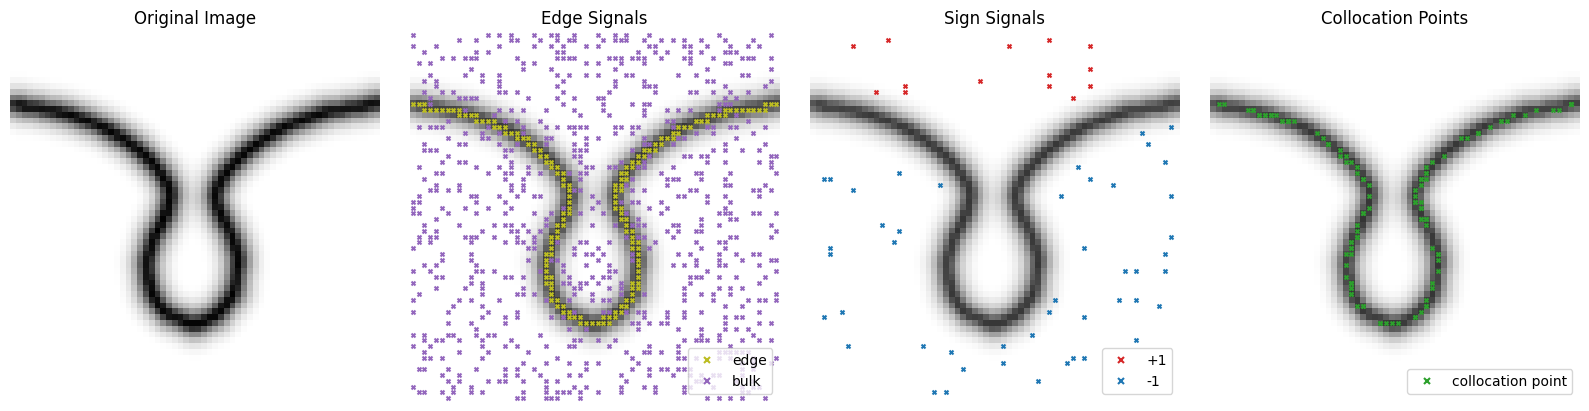

In [6]:
from data_generation.preprocess import plot_sampling_points

axis = "x"
slice_index = 32

# plot_sampling_points(cryoET_data, data_edge, data_sign, data_phys, axis=axis, slice_index=slice_index)
plot_sampling_points(cryoET_data, data_edge, data_sign, data_curv, axis=axis, slice_index=slice_index)

### Load Data 

In [5]:
from pinn.utils import load_pts_data
from pinn.cryoet_io import load_mrc_data

# shape = "biconcave"
shape = "bud_04"
GRID_SIZE = 64
# mrc_file_path = f"../data/synthetic/combine/{shape}_a{str_add}_m{str_miss}.mrc"
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

pts_path = f"../data/synthetic/pts_data"
# data_edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}.npz")
data_sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz")
data_phys = load_pts_data(f"{pts_path}/phys/p_{shape}.npz")
data_curv = load_pts_data(f"{pts_path}/curv/c_{shape}.npz")

### Save Data

In [11]:
from pinn.utils import save_pts_data

save_data_dir = f"../data/synthetic/pts_data"
# save_pts_data(data_sign, f"{save_data_dir}/sign/s_{shape}.npz", meta_sign)
# save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}.npz", meta_phys)
# save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}_b3_n80000.npz", meta_phys)
save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", meta_edge)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_w00_t60.npz", meta_edge)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a000_m00.npz", meta_edge)

# save_pts_data(data_curv, f"{save_data_dir}/curv/c_{shape}.npz", meta_curv)

In [70]:
path = f"{save_data_dir}/phys/p_{shape}.npz"

npz = np.load(path, allow_pickle=True)
for k in npz.files:
    a = npz[k]
    print(k, a.dtype, a.shape)


points float32 (40000, 3)
meta object ()


## manually appending data

In [54]:
import jax.numpy as jnp

new_points = jnp.array([[-0.061887  , -0.026523  ,  0.08661418],
       [ 0.0335958 , -0.0477414 ,  0.08661418],
       [ 0.008841  ,  0.0229866 ,  0.08661418],
       [-0.23517062,  0.00176822,  0.18110237],
       [ 0.15383334, -0.18212464,  0.18110237],
       [ 0.09017824,  0.18212458,  0.18110237],
       [ 0.1467606 , -0.02298659,  0.1496063 ],
       [-0.18212464, -0.04420501,  0.1496063 ],
       [-0.0371322 , -0.17151539,  0.1496063 ],
       [ 0.10432386, -0.0123774 ,  0.13385814],
       [-0.1113966 , -0.0053046 ,  0.13385826],
       [-0.1396878 ,  0.1184694 ,  0.16535433],
       [-0.19273381, -0.0229866 ,  0.16535433],
       [-0.0901782 , -0.1891974 ,  0.16535433],
       [ 0.1078602 , -0.1785882 ,  0.16535433],
       [ 0.1785882 , -0.0654234 ,  0.16535433],
       [ 0.1467606 ,  0.1007874 ,  0.16535433]], dtype=jnp.float32)

new_labels = jnp.array([ 1.,  1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1.], dtype=jnp.float32)

# Append
data_sign = {
    "points": jnp.concatenate([data_sign["points"], new_points], axis=0),
    "label":  jnp.concatenate([data_sign["label"],  new_labels], axis=0),
}


In [15]:
from pinn.plot import write_vtk_point_cloud
from pinn.utils import load_pts_data

shape = "biconcave"
additive = 0.00
missing  = 0.0

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

pts_path = f"../data/synthetic/pts_data"
# data_edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", perm=(2,1,0))
# data_sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz", perm=(2,1,0))
data_phys = load_pts_data(f"{pts_path}/phys/p_biconcave_b3_n80000.npz", perm=(2,1,0))

# write_vtk_point_cloud(
#     "pts_data_edge.vtk",
#     data_edge["points"],
#     point_scalars={"label": data_edge["label"]}
# )

# write_vtk_point_cloud(
#     "pts_data_sign.vtk",
#     data_sign["points"],
#     point_scalars={"label": data_sign["label"]}
# )

write_vtk_point_cloud(
    "pts_data_phys_b3_n80000.vtk",
    data_phys["points"]
)

In [22]:
data_phys

{'points': array([[-0.11477542,  0.5860336 ,  0.39852142],
        [-0.263072  , -0.42185783,  0.3510704 ],
        [-0.5878868 ,  0.11146736, -0.03128195],
        ...,
        [-0.7016969 , -0.780535  ,  0.8310201 ],
        [-0.20330524,  0.8133426 , -0.8586104 ],
        [-0.08871746, -0.49638128,  0.24748492]],
       shape=(40000, 3), dtype=float32),
 'label': None,
 'meta': {'type': 'phys',
  'n_sample': 40000,
  'seed': 0,
  'sampling': 'intensity',
  'phi_fn': '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0926/clean/sphere/lambda_1000000_50/checkpoint_10000'}}

In [57]:
data_curv

{'points': array([[-0.19506574, -0.14114618,  0.40266633],
        [ 0.46461844, -0.20779753, -0.49312496],
        [ 0.5319977 ,  0.14512467, -0.511225  ],
        ...,
        [-0.14729881,  0.04049778, -0.0371902 ],
        [-0.68871903,  0.05151153, -0.55319166],
        [ 0.09844923, -0.09759068, -0.06567764]],
       shape=(5000, 3), dtype=float32),
 'label': None,
 'meta': {'type': 'curv',
  'n_sample': 5000,
  'seed': 0,
  'phi_fn': '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0926/clean/sphere/lambda_1000000_50/checkpoint_10000'}}